In [ ]:
# ── Setup: put src/ on the path, then build the analysis dataframe through the
#    configurable merger. All data paths live in src/config.py.
import os, sys
_p = os.getcwd()
while _p != os.path.dirname(_p):
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, os.path.join(_p, "src")); break
    _p = os.path.dirname(_p)

from data_load import load_data_for_modeling, load_and_clean_accident_data
import ruptures as rpt
import os
from typing import Dict, Optional, Tuple, Any
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from analysis_data import build_analysis_dataframe

df_merged = build_analysis_dataframe(level="person")

count    1,439,347.00
mean            35.81
std             20.04
min             -1.00
25%             22.00
50%             34.00
75%             49.00
max            101.00
Name: person_age, dtype: object


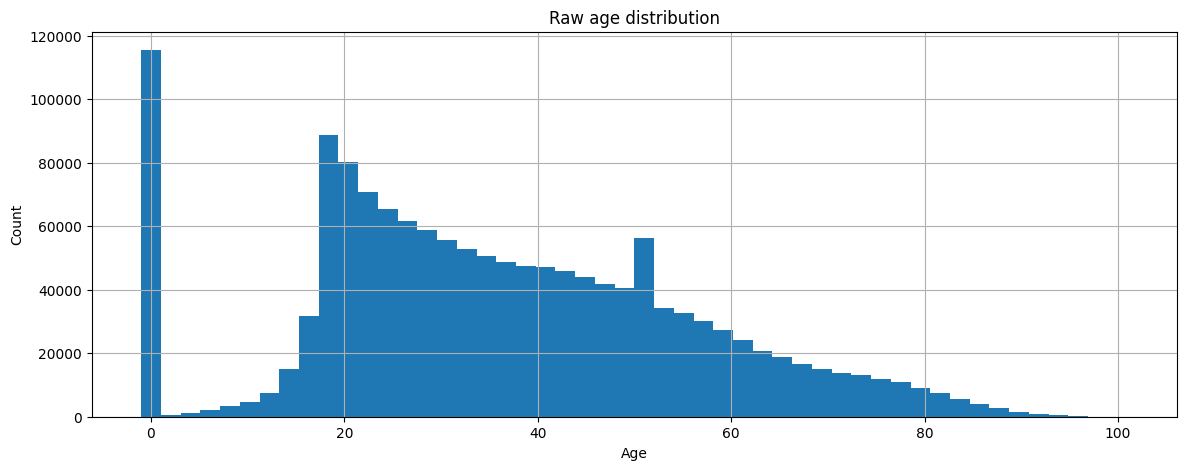

In [9]:
# investigate age distribution
# 1. Basic stats
print(df_merged["person_age"].describe().apply(lambda x: f"{x:,.2f}"))

# 2. Raw distribution
df_merged["person_age"].hist(bins=50, figsize=(14, 5))
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Raw age distribution")
plt.show()

In [10]:
bins   = [-2,0, 20, 25, 35, 45, 60, 101]
labels = ["Unknown", "0-20", "21-25", "26-35", "36-45", "46-60", "61+"]
df_merged["age_group"] = pd.cut(df_merged["person_age"], bins=bins, labels=labels)


In [11]:
# looking at the age group per year, then group then by age group, year, and accident type to see how they aredistributed
df_merged["year"] = pd.to_datetime(df_merged["accident_date"]).dt.year
age_group_distribution = df_merged.groupby(["year", "age_group", "main_situation_class"]).size().reset_index(name="count")
age_group_distribution

/tmp/ipykernel_1190999/2059741113.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_distribution = df_merged.groupby(["year", "age_group", "main_situation_class"]).size().reset_index(name="count")


,year,age_group,main_situation_class,count
0,1985,Unknown,0,1667
1,1985,Unknown,1,965
2,1985,Unknown,2,197
3,1985,Unknown,3,199
4,1985,Unknown,4,80
...,...,...,...,...
2865,2025,61+,5,665
2866,2025,61+,6,875
2867,2025,61+,7,569
2868,2025,61+,8,525


In [12]:
import pandas as pd

# --- drunk driving masks ---
mask_main = df_merged["topic_main_0_3"].isin([6, 15])
mask_acc  = df_merged["topic_acc_cat_0_25"] == 3

# --- yearly totals (denominator) ---
yearly_totals = df_merged.groupby("year").size().rename("total")

# --- main merged T6+T15 by year and age group ---
main_drunk = (
    df_merged[mask_main]
    .groupby(["year", "age_group"], observed=True)
    .size()
    .reset_index(name="count")
)
main_drunk = main_drunk.merge(yearly_totals, on="year")
main_drunk["proportion"] = main_drunk["count"] / main_drunk["total"]

# --- accident_category T3 by year and age group ---
acc_drunk = (
    df_merged[mask_acc]
    .groupby(["year", "age_group"], observed=True)
    .size()
    .reset_index(name="count")
)
acc_drunk = acc_drunk.merge(yearly_totals, on="year")
acc_drunk["proportion"] = acc_drunk["count"] / acc_drunk["total"]


In [13]:
def get_penalty(criterion, n):
    criterion = criterion.lower()
    if criterion == "aic":
        return 2
    elif criterion == "bic":
        return np.log(n)
    elif criterion == "mbic":
        return 3 * np.log(n)


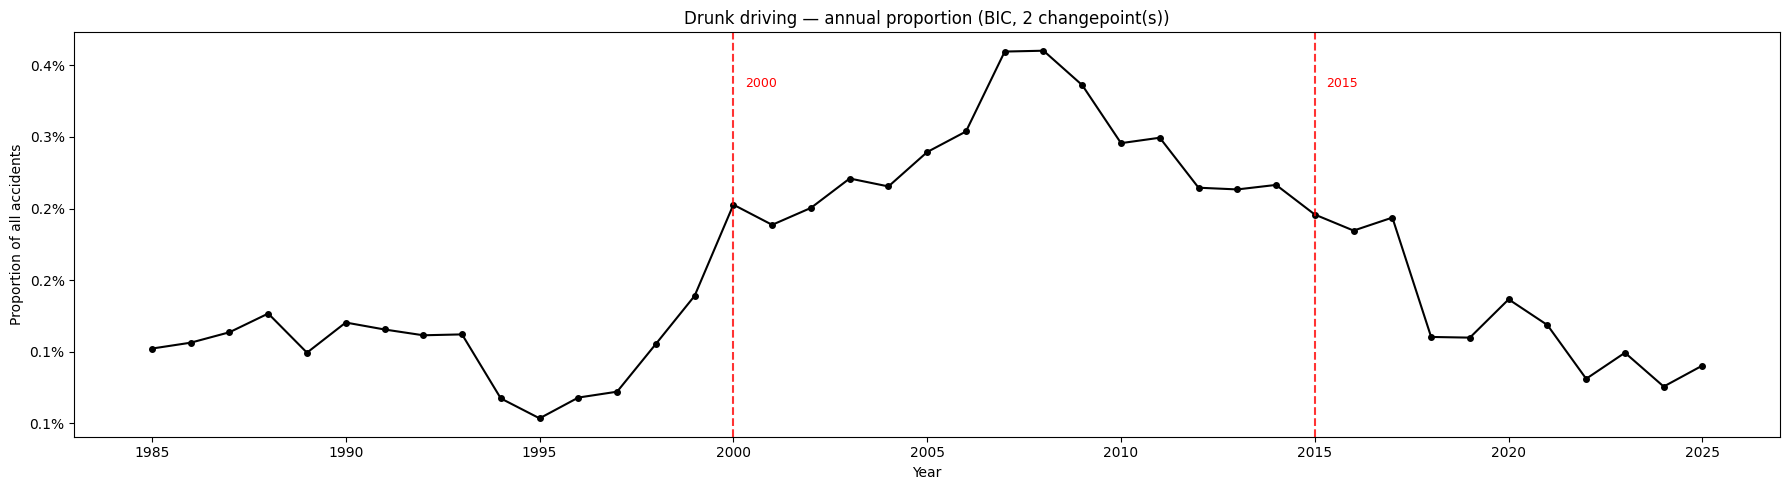

Changepoint years: [2000, 2015]


In [14]:
def plot_drunk_driving_trend(df_raw, title="Drunk driving — annual proportion",
                              figsize=(18, 5), criterion="bic"):
    series = (
        df_raw.groupby("year")[["count", "total"]]
        .sum()
        .sort_index()
        .assign(proportion=lambda d: d["count"] / d["total"])
        ["proportion"]
    )

    n = len(series)
    penalty = get_penalty(criterion, n)

    algo = rpt.Pelt(model="rbf").fit(series.values.reshape(-1, 1))
    breakpoints = algo.predict(pen=penalty)[:-1]
    breakpoint_years = [series.index[bp] for bp in breakpoints]

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(series.index, series.values, color="black", marker="o",
            linewidth=1.5, markersize=4)

    for year in breakpoint_years:
        ax.axvline(x=year, color="red", linestyle="--", alpha=0.8)
        ax.text(year + 0.3, series.max() * 0.95, str(year),
                color="red", fontsize=9, ha="left", va="top")

    ax.set_title(f"{title} ({criterion.upper()}, {len(breakpoint_years)} changepoint(s))")
    ax.set_xlabel("Year")
    ax.set_ylabel("Proportion of all accidents")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    plt.tight_layout()
    plt.show()
    print(f"Changepoint years: {breakpoint_years}")


plot_drunk_driving_trend(main_drunk, criterion="bic")

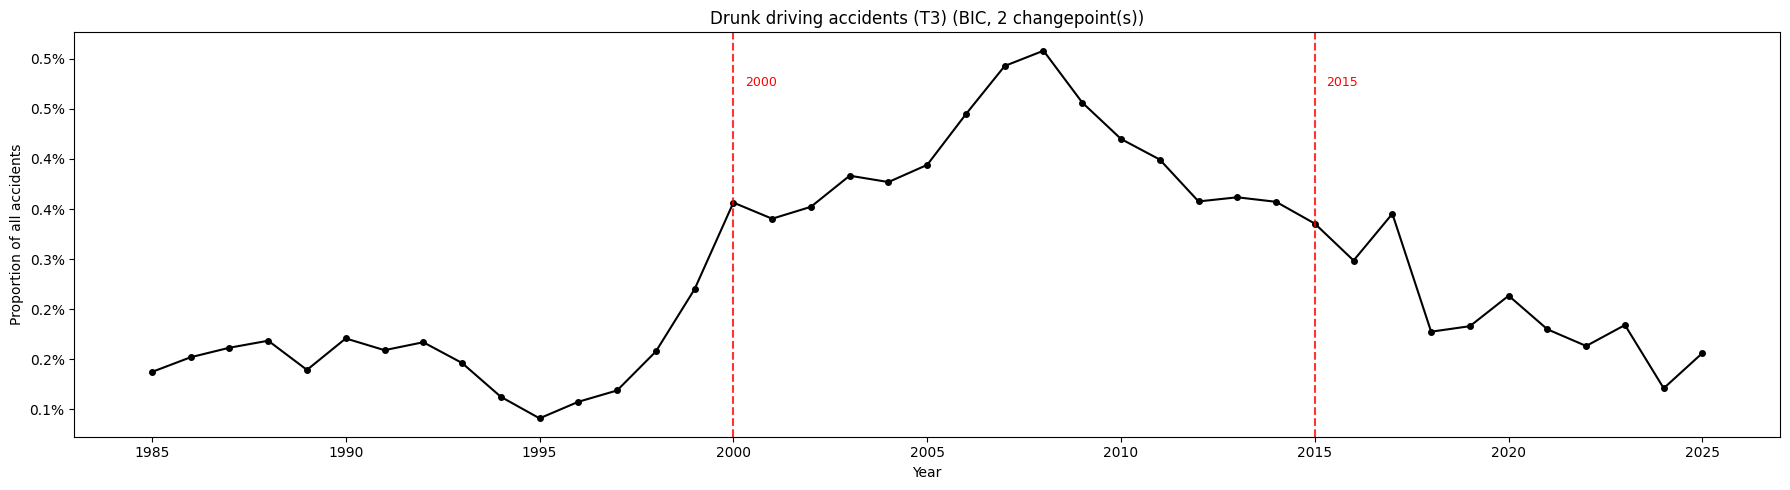

Changepoint years: [2000, 2015]


In [15]:
plot_drunk_driving_trend(acc_drunk, title="Drunk driving accidents (T3)", criterion="bic")

In [16]:
def plot_drunk_driving_by_age(df_raw, title="Drunk driving by age group",
                               figsize=(18, 6), criterion="bic"):
    df_raw = df_raw.dropna(subset=["proportion", "year", "age_group"])

    counts = df_raw.pivot_table(
        index="year",
        columns="age_group",
        values="proportion",
        aggfunc="sum",
        fill_value=0
    )

    fig, ax = plt.subplots(figsize=figsize)

    for age_group in counts.columns:
        series = counts[age_group]
        n = len(series)
        penalty = get_penalty(criterion, n)

        algo = rpt.Pelt(model="rbf").fit(series.values.reshape(-1, 1))
        breakpoints = algo.predict(pen=penalty)[:-1]
        breakpoint_years = [series.index[bp] for bp in breakpoints]

        ax.plot(series.index, series.values, marker="o", linewidth=1.5,
                markersize=4, label=age_group)

        for year in breakpoint_years:
            ax.axvline(x=year, color="red", linestyle="--", alpha=0.5)
            ax.text(year + 0.3, series.max(), str(year), color="red",
                    fontsize=8, ha="left", va="top")

    ax.set_title(f"{title} ({criterion.upper()})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Proportion of all accidents")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    ax.legend(title="Age group", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_1190999/3492181219.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts = df_raw.pivot_table(


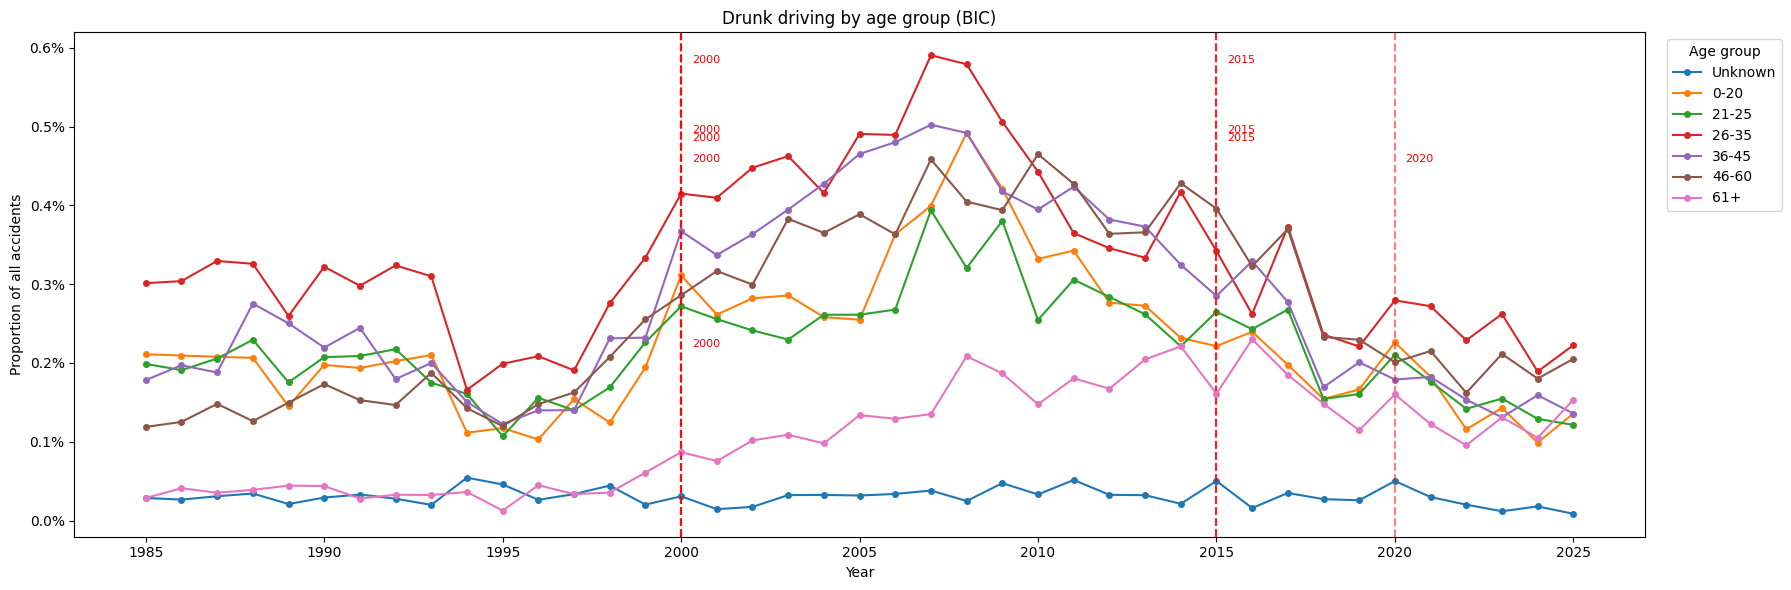

In [17]:
plot_drunk_driving_by_age(main_drunk)

/tmp/ipykernel_1190999/3492181219.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts = df_raw.pivot_table(


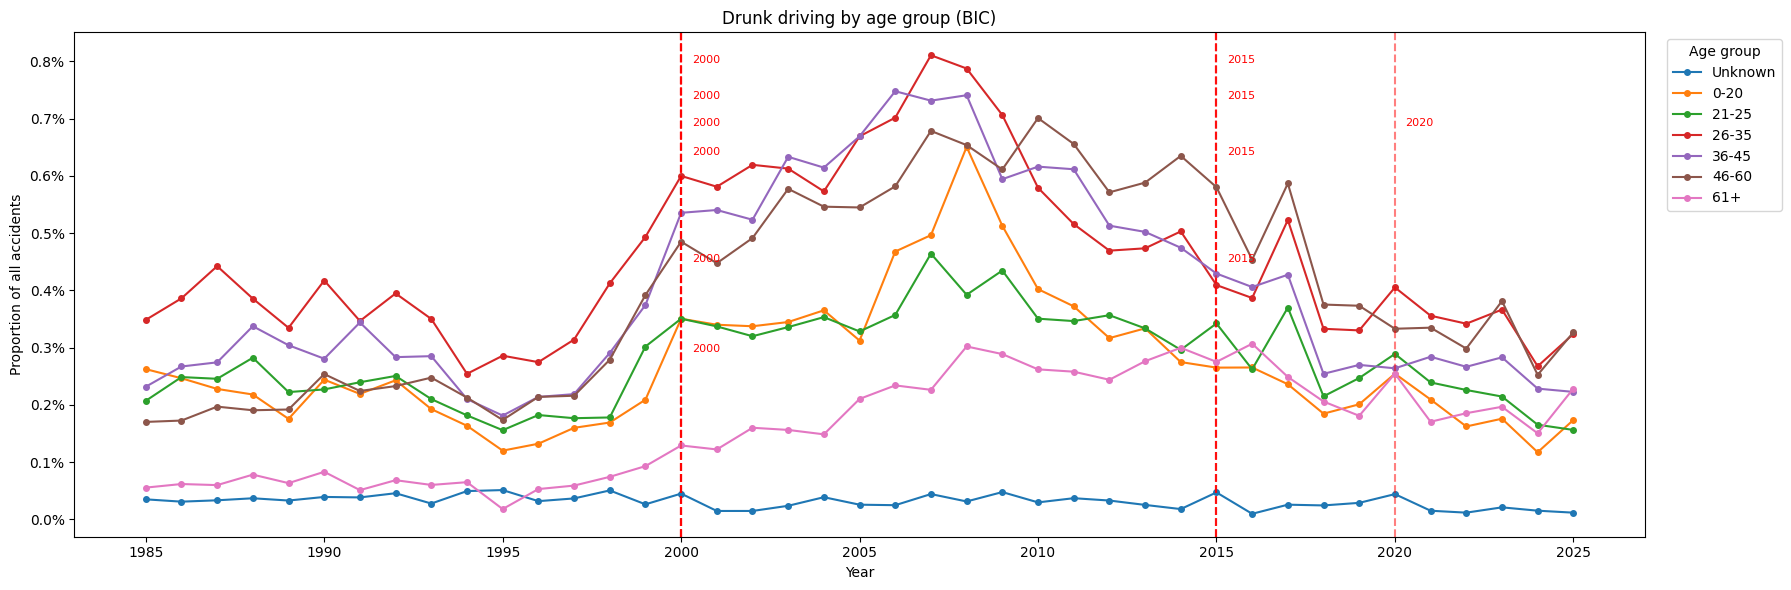

In [18]:
plot_drunk_driving_by_age(acc_drunk)

In [19]:
def summarise_drunk_driving_changepoints(df_raw, criterion="bic"):

    counts = df_raw.pivot_table(
        index="year",
        columns="age_group",
        values="count",
        aggfunc="sum",
        fill_value=0
    )

    totals = df_raw.pivot_table(
        index="year",
        columns="age_group",
        values="total",
        aggfunc="first",   # total is the same for every age group in a given year
        fill_value=np.nan
    )

    props = counts.div(totals)

    results = []

    for age_group in props.columns:
        series = props[age_group].dropna().sort_index()
        n = len(series)
        if n < 2:
            continue
        penalty = get_penalty(criterion, n)

        algo = rpt.Pelt(model="rbf").fit(series.values.reshape(-1, 1))
        breakpoints = algo.predict(pen=penalty)[:-1]
        breakpoint_years = [series.index[bp] for bp in breakpoints]

        for year in breakpoint_years:
            before = series[series.index < year].tail(3).mean()
            after  = series[series.index >= year].head(3).mean()
            direction = "↑ increase" if after > before else "↓ decrease"
            results.append({
                "age_group":        age_group,
                "changepoint_year": year,
                "direction":        direction,
                "before_avg":       round(before, 4),
                "after_avg":        round(after, 4),
            })

    summary = pd.DataFrame(results).sort_values(["changepoint_year", "age_group"])
    print(summary.to_string(index=False))

summarise_drunk_driving_changepoints(main_drunk,criterion="bic")

/tmp/ipykernel_1190999/3438546226.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts = df_raw.pivot_table(
/tmp/ipykernel_1190999/3438546226.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  totals = df_raw.pivot_table(


age_group  changepoint_year  direction  before_avg  after_avg
     0-20              2000 ↑ increase      0.0016     0.0028
    26-35              2000 ↑ increase      0.0027     0.0042
    36-45              2000 ↑ increase      0.0020     0.0036
    46-60              2000 ↑ increase      0.0021     0.0030
      61+              2000 ↑ increase      0.0004     0.0009
     0-20              2015 ↓ decrease      0.0026     0.0022
    26-35              2015 ↓ decrease      0.0037     0.0033
    36-45              2015 ↓ decrease      0.0036     0.0030
    46-60              2020 ↓ decrease      0.0028     0.0019


In [20]:
summarise_drunk_driving_changepoints(acc_drunk)

age_group  changepoint_year  direction  before_avg  after_avg
     0-20              2000 ↑ increase      0.0018     0.0034
    21-25              2000 ↑ increase      0.0022     0.0034
    26-35              2000 ↑ increase      0.0041     0.0060
    36-45              2000 ↑ increase      0.0029     0.0053
    46-60              2000 ↑ increase      0.0030     0.0047
      61+              2000 ↑ increase      0.0008     0.0014
     0-20              2015 ↓ decrease      0.0031     0.0026
    21-25              2015 ↓ decrease      0.0033     0.0032
    26-35              2015 ↓ decrease      0.0048     0.0044
    36-45              2015 ↓ decrease      0.0050     0.0042
    46-60              2020 ↓ decrease      0.0044     0.0032


/tmp/ipykernel_1190999/3438546226.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts = df_raw.pivot_table(
/tmp/ipykernel_1190999/3438546226.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  totals = df_raw.pivot_table(


In [21]:
# load the drunk driving flag data (path from src/config.py)
from config import DRUNK_FLAG_FILE
drunk_flag = pd.read_excel(DRUNK_FLAG_FILE)

/home/s215005/traffic_project/Thesis-traffic-safety/.venv/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [22]:
# remove the first two rwos and make row 1 the header
drunk_flag = drunk_flag[2:] #take the data less the header row
drunk_flag.columns = ["drunk_flag","accident_id"] #set the header row as the df header

In [23]:
df_merged_drunk = pd.merge(df_merged, drunk_flag, on="accident_id", how="left")

In [25]:
mask_topic3 = df_merged_drunk["topic_acc_cat_0_25"] == 3
mask_flag = (
    df_merged_drunk["drunk_flag"].notna() & 
    (df_merged_drunk["drunk_flag"] != 0) & 
    (df_merged_drunk["drunk_flag"] != 999) &
    (df_merged_drunk["drunk_flag"] >= 51)
)

in_both = (mask_topic3 & mask_flag).sum()
in_topic_only = (mask_topic3 & ~mask_flag).sum()
in_flag_only = (~mask_topic3 & mask_flag).sum()
in_neither = (~mask_topic3 & ~mask_flag).sum()

topic3_count = mask_topic3.sum()
flag_count = mask_flag.sum()

print(f"Total in topic 3:                 {topic3_count:,}")
print(f"Total flagged (spritulykke):       {flag_count:,}")
print(f"\nIn topic 3 AND flagged:           {in_both:,}")
print(f"In topic 3 but NOT flagged:       {in_topic_only:,}")

print(f"\nPrecision (% of topic 3 flagged): {in_both/topic3_count:.1%}")


Total in topic 3:                 27,826
Total flagged (spritulykke):       144,872

In topic 3 AND flagged:           22,379
In topic 3 but NOT flagged:       5,447

Precision (% of topic 3 flagged): 80.4%


In [32]:
na_in_topic3 = (mask_topic3 & df_merged_drunk["drunk_flag"].isna()).sum()
zero_in_topic3 = (mask_topic3 & (df_merged_drunk["drunk_flag"] == 0)).sum()
nnn_in_topic3 = (mask_topic3 & (df_merged_drunk["drunk_flag"] == 999)).sum()

print(f"In topic 3 with NaN drunk_flag:  {na_in_topic3:,}")
print(f"In topic 3 with 0 drunk_flag:    {zero_in_topic3:,}")
print(f"In topic 3 with 999 drunk_flag:  {nnn_in_topic3:,}")

In topic 3 with NaN drunk_flag:  394
In topic 3 with 0 drunk_flag:    1,491
In topic 3 with 999 drunk_flag:  2,684


In [25]:
# get documents that are flagged but NOT in topic 3
flag_only_mask = (~mask_topic3) & mask_flag

# sample 10 narratives
flag_only_sample = df_merged_drunk[flag_only_mask]["police_narrative"].sample(10, random_state=42)

for i, (idx, text) in enumerate(flag_only_sample.items()):
    print(f"\n--- doc {idx} ---")
    print(text)



--- doc 410716 ---
part 2 holdt i krydset vollsmose alle, hvorunder part 1 påkørte part 2 i denne højre fordør og fortsatte kørslen. 

--- doc 626416 ---
Part 1 kørte ad Bornholmsgade i sydlig retning og herunder påkørte han personbil TU 99.999- rød Honda- der holdt parkeret ud for Bornholmsgade nr. 80 med retning mod nord. Part 1 forsvandt fra stedet efter påkørslen.

--- doc 589909 ---
Part 1 påkørte part 2 direkte bagfra. Det er endnu uvidst om part 2 var kørende eller om han trak sin knallert. Part 1 kørte mod øst. Påkørslen skete midt i den østgående vognbane.

--- doc 861179 ---
Færdselsuheld med flugt fra stedet, gerningsmanden kørte i personbil reg. YD99999

--- doc 1095827 ---
Ved patruljens ankomst kunne det konstateres, at Part1, cyklist, havde påkørt Part2, parkeret personbil, hvilket havde resulteret i at personbilen havde fået knust sin bagrude samt højre baglygte. Part1 havde pådraget sig en mindre flænge på hagen. Part2 var ikke tilstedet, idet han havde lånt personbil

In [26]:
# get documents in topic 3 but NOT flagged
topic_only_mask = mask_topic3 & (~mask_flag)

# sample 10 narratives
topic_only_sample = df_merged_drunk[topic_only_mask]["police_narrative"].sample(10, random_state=42)

for i, (idx, text) in enumerate(topic_only_sample.items()):
    print(f"\n--- doc {idx} ---")
    print(text)


--- doc 828382 ---
Part 1 kørte ad Frederikssundsvej mod NW. Vand på kørebanen efter kraftig nedbør - hvorved han skred ud og påkørte en lyssignalstander tilh. part 2. Alkotestet til 0,16 promille. Ingen blodprøve.

--- doc 1300220 ---
Part 1 forsøgte at køre fra en politipatrulje og kørte i sydøstlig retning ad Vadum Kirkevej. Ved T krydset Hvorupgårdvej forsøgte han at foretage et højresving, men grundet for høj hastighed, ramte han rabatten og et elskab på modsatte side af vejen. Ingen personskade og mindre skade på elskab og forreste kofanger. Part 1 var kørende i en sort Opel Vectra med efterlyste nummerplader AB99999. Da part 1 kørte galt, var politipatruljen ca. 170 meter efter og foretog umiddelbart herefter anholdelse af part 1. Narkometertest viste positiv for amfetamin og cannabis. Blodprøve udtaget.

--- doc 1119033 ---
FUH og mulig spiritusbilist. med anhænger kørte ad Møllevej hvor føreren mistede herredømmet over køretøjet og ramte en carport med 2 biler. Carport og bil

In [30]:
mask_topic3  = df_merged_drunk["topic_acc_cat_0_25"] == 3          # topic model label
mask_no_test = df_merged_drunk["drunk_flag"].isna()                 # NaN → no test
mask_sober   = df_merged_drunk["drunk_flag"].isin([0, 999])         # tested but sober
mask_spirituskorsel = (df_merged_drunk["drunk_flag"] >= 51) & (df_merged_drunk["drunk_flag"] <= 888)


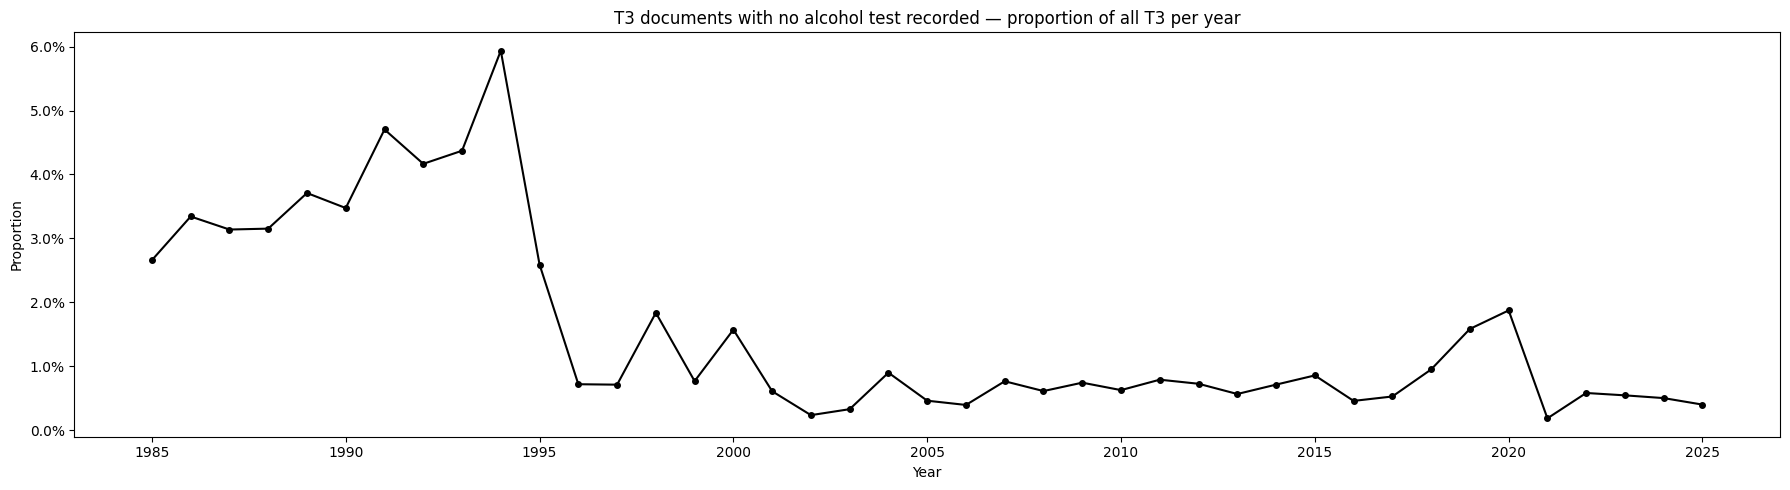

In [ ]:
mask_no_test = df_merged_drunk["drunk_flag"].isna()

yearly_drunk_total = (
    df_merged_drunk[mask_topic3]
    .groupby("year")
    .size()
    .rename("drunk_total")
)

no_test = (
    df_merged_drunk[mask_topic3 & mask_no_test]
    .groupby("year")
    .size()
    .reset_index(name="count")
    .merge(yearly_drunk_total, on="year")
    .assign(proportion=lambda d: d["count"] / d["drunk_total"])
    .set_index("year")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(no_test.index, no_test["proportion"],
        color="black", marker="o", linewidth=1.5, markersize=4)

ax.set_title("T3 documents with no alcohol test recorded — proportion of all T3 per year")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.show()

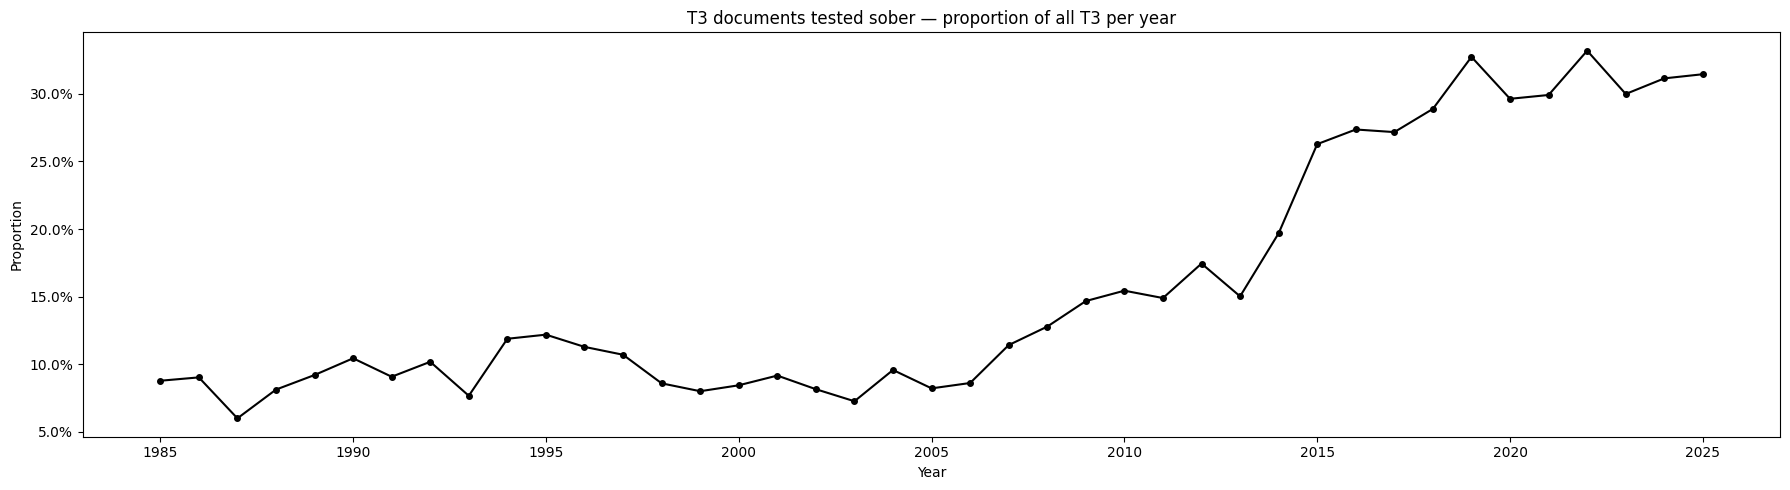

In [29]:
yearly_drunk_total = (
    df_merged_drunk[mask_topic3]
    .groupby("year")
    .size()
    .rename("drunk_total")
)

sober = (
    df_merged_drunk[mask_topic3 & mask_sober]
    .groupby("year")
    .size()
    .reset_index(name="count")
    .merge(yearly_drunk_total, on="year")
    .assign(proportion=lambda d: d["count"] / d["drunk_total"])
    .set_index("year")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sober.index, sober["proportion"],
        color="black", marker="o", linewidth=1.5, markersize=4)

ax.set_title("T3 documents tested sober — proportion of all T3 per year")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.show()


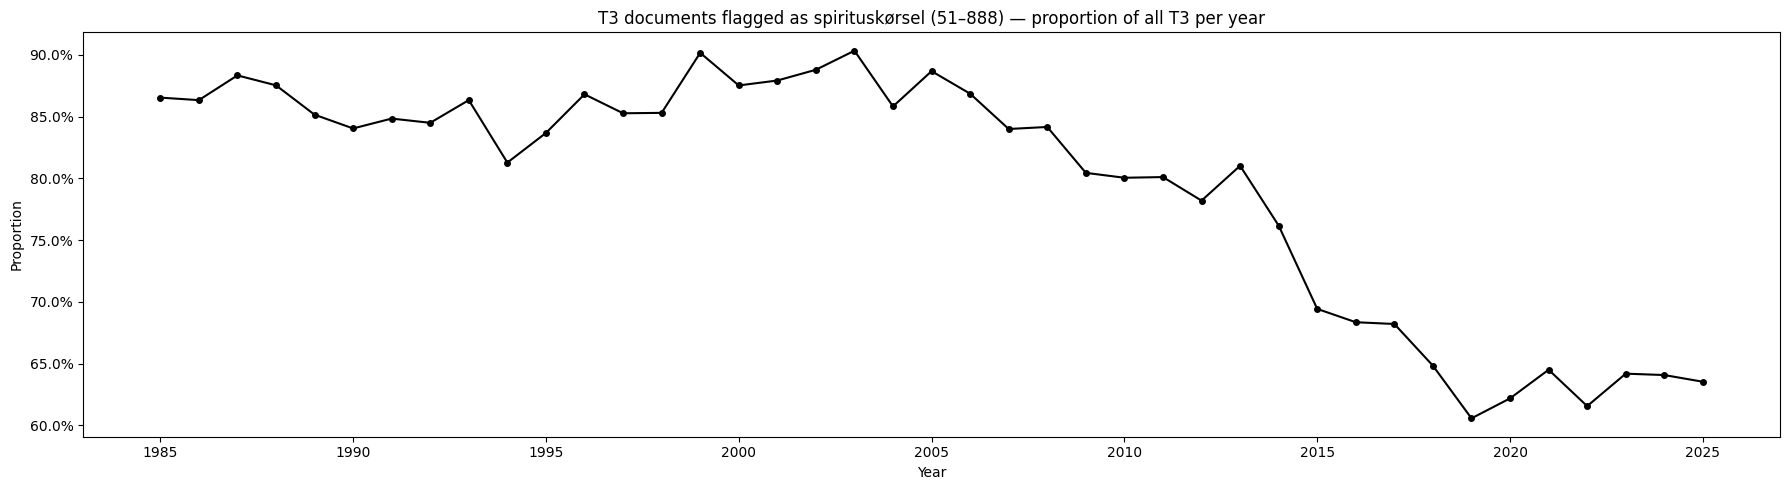

In [31]:
spirituskorsel = (
    df_merged_drunk[mask_topic3 & mask_spirituskorsel]
    .groupby("year")
    .size()
    .reset_index(name="count")
    .merge(yearly_drunk_total, on="year")
    .assign(proportion=lambda d: d["count"] / d["drunk_total"])
    .set_index("year")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(spirituskorsel.index, spirituskorsel["proportion"],
        color="black", marker="o", linewidth=1.5, markersize=4)

ax.set_title("T3 documents flagged as spirituskørsel (51–888) — proportion of all T3 per year")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.show()


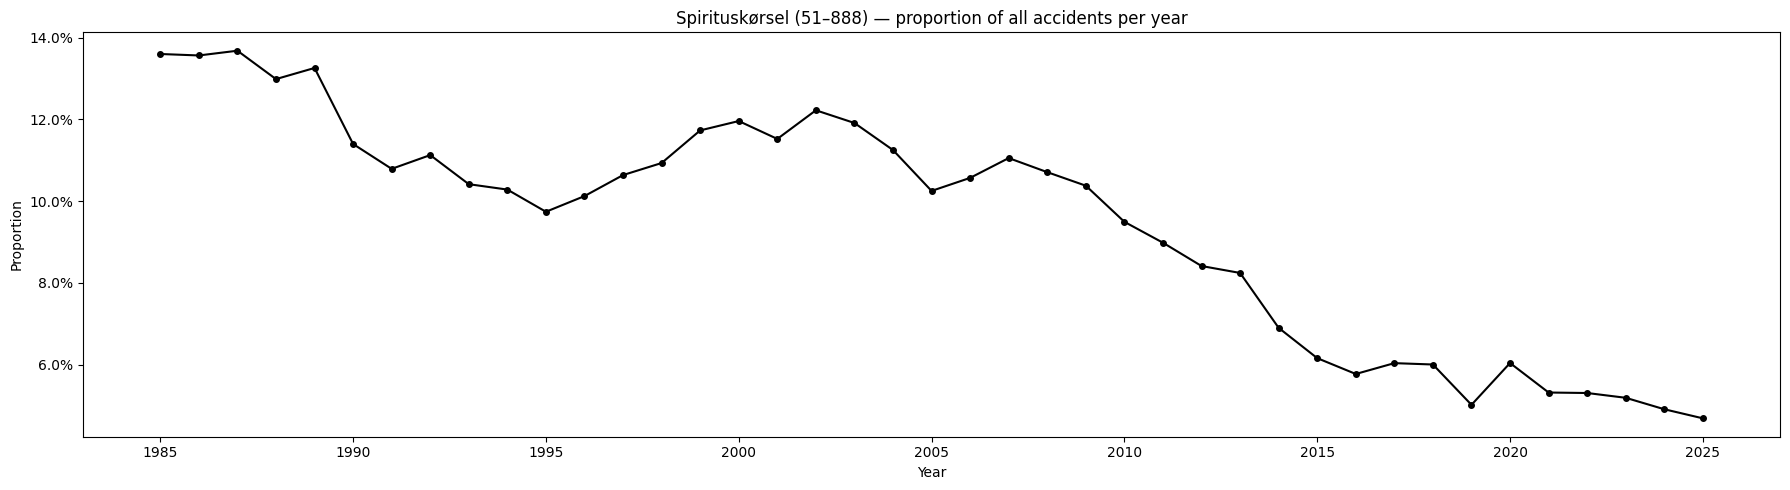

In [33]:
mask_spirituskorsel = (
    ((df_merged_drunk["year"] < 1998) & (df_merged_drunk["drunk_flag"] > 81) & (df_merged_drunk["drunk_flag"] <= 888)) |
    ((df_merged_drunk["year"] >= 1998) & (df_merged_drunk["drunk_flag"] >= 51) & (df_merged_drunk["drunk_flag"] <= 888))
)
yearly_total = df_merged_drunk.groupby("year").size().rename("total")

spirituskorsel_all = (
    df_merged_drunk[mask_spirituskorsel]
    .groupby("year")
    .size()
    .reset_index(name="count")
    .merge(yearly_total, on="year")
    .assign(proportion=lambda d: d["count"] / d["total"])
    .set_index("year")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(spirituskorsel_all.index, spirituskorsel_all["proportion"],
        color="black", marker="o", linewidth=1.5, markersize=4)

ax.set_title("Spirituskørsel (51–888) — proportion of all accidents per year")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.show()